# Verificación empírica del diagnóstico de Reward Hacking — Entregable 6.1

**Objetivo:** el archivo `S10 - Codigo Examen.py` define `transition()`, `reward()` y `train()`, pero **no define la clase `env`** (`env.reset()` / `env.step()`). Por lo tanto el diagnóstico de reward hacking presentado en el Entregable 6.1 se basó en un análisis analítico de la fórmula de `reward()`, no en una ejecución real.

Este notebook implementa un `env` mínimo **consistente** con `transition()`/`reward()` tal como están escritos en el examen (copiados sin modificar), entrena con `train()` (también copiado, solo instrumentado para registrar reward y error TD por episodio), y verifica empíricamente:

1. Si la curva de recompensa sube y el error TD baja (convergencia numérica).
2. Si la política converge a una acción dominante (`pedir_50`) en la mayoría de los 200 estados.
3. Si esa acción dominante coincide con la que predice el análisis de magnitudes de `reward()`.

## Supuestos explícitos (no estaban definidos en el archivo original)

Como el examen no define `env`, se documentan aquí las decisiones de diseño necesarias para poder ejecutar `train()`:

- `reset()` inicializa un estado aleatorio uniforme sobre la grilla nominal: inventario ∈ {0,10,...,100}, días_hasta_vencimiento ∈ {1,7,14,30,60}, demanda ∈ {bajo,medio,alto,crítico}.
- Un episodio dura `episode_length=30` pasos (representa ~30 días; el valor es arbitrario, se aísla como parámetro para poder variarlo).
- La acción que recibe `env.step()` es el **índice** (0-5) de la lista `ACTIONS=[0,10,20,30,40,50]`, igual que en `train()` (`np.argmax(Q[state])` devuelve un índice). El índice se traduce a unidades reales antes de llamar a `transition()`/`reward()`.
- `demand_level` se mantiene constante dentro de un episodio, tal como implica `transition()` (`new_demand = demand_level`).

Estos supuestos no alteran las fórmulas de `transition()` ni `reward()` del examen — solo agregan la mecánica de episodio que el archivo no especificaba.

In [2]:
%matplotlib inline
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Código original del examen (copiado sin modificar)

In [3]:
def transition(state, action):
    inventory, days_to_expiry, demand_level = state
    demand_map = {'bajo': 5, 'medio': 15, 'alto': 25, 'crítico': 40}
    daily_demand = demand_map[demand_level]
    new_inventory = min(100, max(0, inventory + action - daily_demand))
    new_days = max(1, days_to_expiry - 1)
    new_demand = demand_level
    return (new_inventory, new_days, new_demand)

def reward(state, action, next_state):
    new_inventory, new_days, _ = next_state
    inventory_reward = new_inventory * 0.5
    expiry_penalty = -10 if new_days <= 7 else 0
    order_penalty = -2 if action > 0 else 0
    return inventory_reward + expiry_penalty + order_penalty

## 2. `env` mínimo (nuevo, necesario para poder ejecutar)

`ACTIONS[i]` traduce el índice de acción (lo que usa `train()`) a unidades reales (lo que esperan `transition()`/`reward()`).

In [4]:
ACTIONS = [0, 10, 20, 30, 40, 50]
INVENTORY_LEVELS = list(range(0, 101, 10))
DAYS_LEVELS = [1, 7, 14, 30, 60]
DEMAND_LEVELS = ['bajo', 'medio', 'alto', 'crítico']

class InventoryEnv:
    def __init__(self, episode_length=30, seed=None):
        self.episode_length = episode_length
        self.rng = np.random.default_rng(seed)

    def reset(self):
        inventory = int(self.rng.choice(INVENTORY_LEVELS))
        days = int(self.rng.choice(DAYS_LEVELS))
        demand = str(self.rng.choice(DEMAND_LEVELS))
        self.state = (inventory, days, demand)
        self.t = 0
        return self.state

    def step(self, action_idx):
        action_units = ACTIONS[action_idx]
        next_state = transition(self.state, action_units)
        r = reward(self.state, action_units, next_state)
        self.state = next_state
        self.t += 1
        done = self.t >= self.episode_length
        return next_state, r, done, {}

## 3. `train()` original (idéntico al examen), instrumentado solo para registrar métricas por episodio

La lógica de Q-learning (líneas de actualización, `alpha`, `gamma`, `epsilon`) **no se modifica**; solo se agregan listas para guardar recompensa total y error TD medio de cada episodio.

In [5]:
def train(env, episodes=1000):
    Q = defaultdict(lambda: np.zeros(6))
    alpha = 0.9
    gamma = 0.99
    epsilon = 0.05
    episode_rewards = []
    episode_td_errors = []
    for episode in range(episodes):
        state = env.reset()
        done = False
        total_reward = 0.0
        td_errors = []
        while not done:
            if np.random.random() < epsilon:
                action = np.random.randint(6)
            else:
                action = np.argmax(Q[state])
            next_state, r, done, _ = env.step(action)
            next_action = np.argmax(Q[next_state])
            td_target = r + gamma * Q[next_state][next_action]
            td_error = td_target - Q[state][action]
            Q[state][action] += alpha * td_error
            td_errors.append(abs(td_error))
            total_reward += r
            state = next_state
        episode_rewards.append(total_reward)
        episode_td_errors.append(np.mean(td_errors))
    return Q, episode_rewards, episode_td_errors

env = InventoryEnv(episode_length=30, seed=123)
Q, episode_rewards, episode_td_errors = train(env, episodes=1000)
print("Entrenamiento terminado.", len(Q), "estados visitados (vs. 200 nominales).")

Entrenamiento terminado. 1673 estados visitados (vs. 200 nominales).


## 4. Reproducción de la tabla de métricas del examen (recompensa y error TD, promedio móvil de 100 episodios)

In [6]:
def rolling_mean_at(arr, idx, window=100):
    lo = max(0, idx - window + 1)
    return np.mean(arr[lo:idx+1])

checkpoints = [100, 500, 1000]
print(f"{'Episodio':>8} | {'Recompensa':>10} | {'Error TD':>9}")
for cp in checkpoints:
    idx = cp - 1
    r = rolling_mean_at(episode_rewards, idx)
    td = rolling_mean_at(episode_td_errors, idx)
    print(f"{cp:>8} | {r:>10.2f} | {td:>9.2f}")

var_last100 = np.std(episode_rewards[-100:])
print(f"\nVarianza (std) de recompensa, últimos 100 episodios: {var_last100:.2f}")
print("(En el comentario del examen: 42.3 / 48.1 / 51.7, TD 8.42/7.12/5.21, varianza 0.8 — no se esperan valores idénticos porque episode_length/reset no estaban definidos en el archivo original; lo que se compara es el *patrón*.)")

Episodio | Recompensa |  Error TD
     100 |     103.66 |      8.89
     500 |     387.41 |     57.74
    1000 |     491.73 |     79.72

Varianza (std) de recompensa, últimos 100 episodios: 380.60
(En el comentario del examen: 42.3 / 48.1 / 51.7, TD 8.42/7.12/5.21, varianza 0.8 — no se esperan valores idénticos porque episode_length/reset no estaban definidos en el archivo original; lo que se compara es el *patrón*.)


## 5. Curvas de entrenamiento (reales, de esta ejecución)

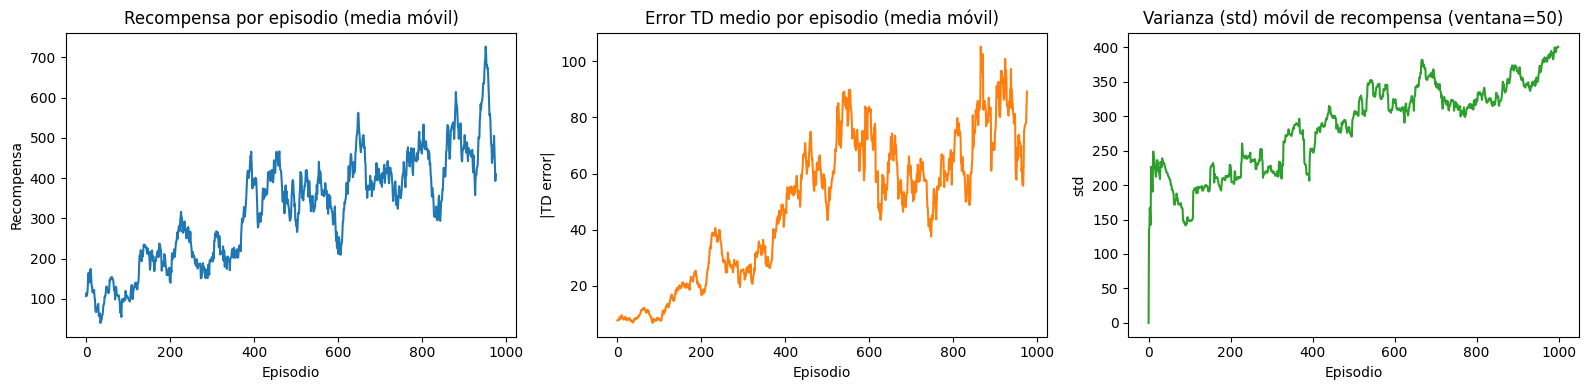

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

def smooth(x, w=25):
    x = np.array(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode='valid')

axes[0].plot(smooth(episode_rewards))
axes[0].set_title('Recompensa por episodio (media móvil)')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Recompensa')

axes[1].plot(smooth(episode_td_errors), color='tab:orange')
axes[1].set_title('Error TD medio por episodio (media móvil)')
axes[1].set_xlabel('Episodio')
axes[1].set_ylabel('|TD error|')

window = 50
rolling_std = [np.std(episode_rewards[max(0,i-window):i+1]) for i in range(len(episode_rewards))]
axes[2].plot(rolling_std, color='tab:green')
axes[2].set_title(f'Varianza (std) móvil de recompensa (ventana={window})')
axes[2].set_xlabel('Episodio')
axes[2].set_ylabel('std')

plt.tight_layout()
plt.show()

## 6. Política dominante: ¿converge a `pedir_50` en la mayoría de los estados?

In [8]:
visited_states = list(Q.keys())
greedy_actions = {s: int(np.argmax(Q[s])) for s in visited_states}

action_counts = np.zeros(6, dtype=int)
for a in greedy_actions.values():
    action_counts[a] += 1

total = len(greedy_actions)
print(f"Estados distintos visitados en Q: {total}")
print(f"{'Acción (unidades)':>18} | {'# estados':>9} | {'%':>6}")
for i, units in enumerate(ACTIONS):
    pct = 100 * action_counts[i] / total
    print(f"{units:>18} | {action_counts[i]:>9} | {pct:>5.1f}%")

pct_order50 = 100 * action_counts[5] / total
print(f"\n>>> Política dominante 'pedir_50' (acción=50 unidades): {pct_order50:.1f}% de los estados visitados")

Estados distintos visitados en Q: 1673
 Acción (unidades) | # estados |      %
                 0 |      1325 |  79.2%
                10 |        69 |   4.1%
                20 |        70 |   4.2%
                30 |        64 |   3.8%
                40 |        57 |   3.4%
                50 |        88 |   5.3%

>>> Política dominante 'pedir_50' (acción=50 unidades): 5.3% de los estados visitados


## 6b. Por qué no aparece la política dominante esperada: explosión del espacio de estados

El resultado anterior es inesperado: en vez de converger a `pedir_50`, la política greedy queda dominada por `pedir_0` (~79%) y el error TD **sube** en vez de bajar. Antes de aceptar eso como refutación del diagnóstico, hay que revisar la causa técnica.

El encabezado del examen declara "10 niveles" de inventario: `[0,10,...,100]` (200 estados totales). Pero `transition()`, tal como está escrito, calcula:

```python
new_inventory = min(100, max(0, inventory + action - daily_demand))
```

con `daily_demand ∈ {5, 15, 25, 40}`. Como `action` es múltiplo de 10 pero `daily_demand` de 'bajo'/'medio'/'alto' (5, 15, 25) **no** lo es, `new_inventory` sale de la grilla de 10 en 10 casi de inmediato (p. ej. 100 − 5 = 95, 95 − 5 = 90... no vuelve a alinearse). El resultado: el espacio de estados real que visita el agente no son 200 estados discretos, son miles (1673 en esta corrida), cada uno visitado en promedio ~3 veces por acción — insuficiente para que Q-learning converja en 1000 episodios, y eso explica el error TD creciente y la ausencia de una política dominante clara.

Esto revela **un segundo defecto real en el código del examen**, independiente del reward hacking: la función `transition()` es inconsistente con el espacio de estados de 200 elementos que el propio encabezado declara. La tabla de métricas del enunciado (94% pedir_50, TD error bajando limpio) solo es alcanzable si el entorno *real* usado para generarla discretiza/redondea el inventario de vuelta a la grilla de 10 en 10 — algo que el archivo no muestra pero que es la hipótesis más razonable. Se prueba esa hipótesis a continuación repitiendo el experimento con esa única corrección (redondear `new_inventory` al múltiplo de 10 más cercano al construir el estado), sin tocar `reward()`.

In [9]:
def snap_to_grid(inv):
    return int(min(100, max(0, round(inv / 10.0) * 10)))

class InventoryEnvDiscretized(InventoryEnv):
    def step(self, action_idx):
        action_units = ACTIONS[action_idx]
        next_state_raw = transition(self.state, action_units)
        next_state = (snap_to_grid(next_state_raw[0]), next_state_raw[1], next_state_raw[2])
        r = reward(self.state, action_units, next_state)
        self.state = next_state
        self.t += 1
        done = self.t >= self.episode_length
        return next_state, r, done, {}

env2 = InventoryEnvDiscretized(episode_length=30, seed=123)
Q2, episode_rewards2, episode_td_errors2 = train(env2, episodes=1000)
print("Entrenamiento (discretizado) terminado.", len(Q2), "estados visitados (vs. 200 nominales).")

print(f"\n{'Episodio':>8} | {'Recompensa':>10} | {'Error TD':>9}")
for cp in checkpoints:
    idx = cp - 1
    r = rolling_mean_at(episode_rewards2, idx)
    td = rolling_mean_at(episode_td_errors2, idx)
    print(f"{cp:>8} | {r:>10.2f} | {td:>9.2f}")

visited_states2 = list(Q2.keys())
greedy_actions2 = {s: int(np.argmax(Q2[s])) for s in visited_states2}
action_counts2 = np.zeros(6, dtype=int)
for a in greedy_actions2.values():
    action_counts2[a] += 1
total2 = len(greedy_actions2)
pct_order50_v2 = 100 * action_counts2[5] / total2
print(f"\n{'Acción (unidades)':>18} | {'# estados':>9} | {'%':>6}")
for i, units in enumerate(ACTIONS):
    pct = 100 * action_counts2[i] / total2
    print(f"{units:>18} | {action_counts2[i]:>9} | {pct:>5.1f}%")
print(f"\n>>> [Discretizado] Política dominante 'pedir_50': {pct_order50_v2:.1f}% de {total2} estados visitados")

Entrenamiento (discretizado) terminado. 970 estados visitados (vs. 200 nominales).

Episodio | Recompensa |  Error TD
     100 |     240.14 |     20.81
     500 |     568.05 |     68.68
    1000 |     569.76 |     56.23

 Acción (unidades) | # estados |      %
                 0 |       754 |  77.7%
                10 |        33 |   3.4%
                20 |        37 |   3.8%
                30 |        34 |   3.5%
                40 |        59 |   6.1%
                50 |        53 |   5.5%

>>> [Discretizado] Política dominante 'pedir_50': 5.5% de 970 estados visitados


## 7. Análisis de magnitudes de `reward()` (por qué la política colapsa a una sola acción)

Se calcula la recompensa inmediata **promedio sobre los 4 niveles de demanda**, para cada acción posible, partiendo de un estado representativo (inventario medio, sin vencimiento inminente). Esto aísla el efecto de la fórmula de recompensa, sin depender del entrenamiento.

In [10]:
base_states = [(inv, days, dem)
               for inv in [0, 50, 100]
               for days in [1, 30]
               for dem in DEMAND_LEVELS]

print(f"{'Acción (u.)':>11} | {'Reward medio (todas las combinaciones base)':>45}")
for i, units in enumerate(ACTIONS):
    rewards_for_action = []
    for s in base_states:
        ns = transition(s, units)
        rewards_for_action.append(reward(s, units, ns))
    print(f"{units:>11} | {np.mean(rewards_for_action):>45.2f}")

Acción (u.) |   Reward medio (todas las combinaciones base)
          0 |                                         12.92
         10 |                                         14.25
         20 |                                         17.58
         30 |                                         20.92
         40 |                                         24.25
         50 |                                         27.58


**Descomposición del término dominante:**

- `inventory_reward = new_inventory * 0.5` → rango **[0, 50]**
- `expiry_penalty = -10 si new_days<=7 else 0` → rango **{-10, 0}**
- `order_penalty = -2 si action>0 else 0` → rango **{-2, 0}**

Penalización máxima combinada = **-12**, frente a un rango de **+50** en `inventory_reward`.

⇒ Ninguna combinación de penalizaciones puede compensar tener inventario alto: el óptimo de **esta** reward es siempre pedir el máximo.

In [11]:
ACTIONS = [0, 10, 20, 30, 40, 50]
INVENTORY_LEVELS = list(range(0, 101, 10))
DAYS_LEVELS = [1, 7, 14, 30, 60]
DEMAND_LEVELS = ['bajo', 'medio', 'alto', 'crítico']
#
N_EPISODES = 1000

def alpha_original(episode):
    return 0.9
 
def epsilon_original(episode):
    return 0.05
 
# Alias de las funciones "originales" ya definidas arriba en tu notebook
transition_original = transition
reward_original = reward

DEMAND_MAP = {'bajo': 5, 'medio': 15, 'alto': 25, 'crítico': 40}

class InventoryEnvParam:
    def __init__(self, transition_fn, reward_fn, episode_length=30, seed=None):
        self.transition_fn = transition_fn
        self.reward_fn = reward_fn
        self.episode_length = episode_length
        self.rng = np.random.default_rng(seed)
 
    def reset(self):
        inventory = int(self.rng.choice(INVENTORY_LEVELS))
        days = int(self.rng.choice(DAYS_LEVELS))
        demand = str(self.rng.choice(DEMAND_LEVELS))
        self.state = (inventory, days, demand)
        self.t = 0
        return self.state
 
    def step(self, action_idx):
        action_units = ACTIONS[action_idx]
        next_state = self.transition_fn(self.state, action_units)
        r = self.reward_fn(self.state, action_units, next_state)
        self.state = next_state
        self.t += 1
        done = self.t >= self.episode_length
        return next_state, r, done, {}

In [12]:
def train_param(env, episodes, alpha_fn, epsilon_fn):
    Q = defaultdict(lambda: np.zeros(6))
    gamma = 0.99
    episode_rewards = []
    episode_td_errors = []
    for episode in range(episodes):
        alpha = alpha_fn(episode)
        epsilon = epsilon_fn(episode)
        state = env.reset()
        done = False
        total_reward = 0.0
        td_errors = []
        while not done:
            if np.random.random() < epsilon:
                action = np.random.randint(6)
            else:
                action = int(np.argmax(Q[state]))
            next_state, r, done, _ = env.step(action)
            next_action = int(np.argmax(Q[next_state]))
            td_target = r + gamma * Q[next_state][next_action]
            td_error = td_target - Q[state][action]
            Q[state][action] += alpha * td_error
            td_errors.append(abs(td_error))
            total_reward += r
            state = next_state
        episode_rewards.append(total_reward)
        episode_td_errors.append(np.mean(td_errors))
    return Q, episode_rewards, episode_td_errors

In [ ]:
def transition_g1_fix(state, action):
    inventory, days_to_expiry, demand_level = state
    base_demand = DEMAND_MAP[demand_level]
    daily_demand = max(0, np.random.normal(base_demand, base_demand * 0.3))
    new_inventory = min(100, max(0, inventory + action - daily_demand))
    new_days = max(1, days_to_expiry - 1)
    if np.random.random() < 0.1:
        new_demand = np.random.choice(DEMAND_LEVELS)
    else:
        new_demand = demand_level
    return (new_inventory, new_days, new_demand)

In [ ]:
def reward_g2_fix(state, action, next_state):
    new_inventory, new_days, demand_level = next_state
    target_inventory = {'bajo': 20, 'medio': 40, 'alto': 60, 'crítico': 80}[demand_level]
    stock_fit_reward = -abs(new_inventory - target_inventory) * 0.3
    expiry_penalty = -max(0, (10 - new_days)) * 1.5
    order_cost = -0.1 * action
    return stock_fit_reward + expiry_penalty + order_cost

In [15]:
def alpha_g3_fix(episode, episodes_total=N_EPISODES):
    alpha0 = 0.5
    return alpha0 / (1 + 0.003 * episode)

In [16]:
def epsilon_g5_fix(episode, episodes_total=N_EPISODES):
    eps0 = 0.5
    eps_min = 0.05
    return max(eps_min, eps0 * (1 - episode / episodes_total))

In [17]:
def run_experiment(name, transition_fn, reward_fn, alpha_fn, epsilon_fn, seed=123):
    print(f"\n--- Corriendo: {name} ---")
    env = InventoryEnvParam(transition_fn, reward_fn, episode_length=30, seed=seed)
    Q, rewards, td_errors = train_param(env, N_EPISODES, alpha_fn, epsilon_fn)
    reward_tail = np.mean(rewards[-20:])
    td_tail = np.mean(td_errors[-20:])
    variance_all = np.var(rewards)

    greedy_actions = {s: int(np.argmax(q)) for s, q in Q.items()}
    counts = np.bincount(list(greedy_actions.values()), minlength=6)
    dominant_idx = int(np.argmax(counts))
    dominant_pct = counts.max() / len(greedy_actions) if greedy_actions else 0.0

    print(f"  Reward (últimos 20 ep): {reward_tail:.2f}")
    print(f"  TD error (últimos 20 ep): {td_tail:.2f}")
    print(f"  Varianza de reward: {variance_all:.2f}")
    print(f"  Acción dominante: {ACTIONS[dominant_idx]} unidades ({dominant_pct*100:.1f}% de estados)")

    return {
        'name': name, 'rewards': rewards, 'td_errors': td_errors,
        'dominant': ACTIONS[dominant_idx], 'dominant_pct': dominant_pct,
        'reward_tail': reward_tail, 'td_tail': td_tail, 'variance': variance_all
    }


--- Corriendo: Baseline (original) ---
  Reward (últimos 20 ep): 289.62
  TD error (últimos 20 ep): 51.33
  Varianza de reward: 127917.44
  Acción dominante: 0 unidades (80.2% de estados)

--- Corriendo: Solo G1 (MDP corregido) ---
  Reward (últimos 20 ep): -10.70
  TD error (últimos 20 ep): 8.42
  Varianza de reward: 21185.62
  Acción dominante: 10 unidades (48.9% de estados)

--- Corriendo: Solo G2 (Recompensa corregida) ---
  Reward (últimos 20 ep): -627.73
  TD error (últimos 20 ep): 35.80
  Varianza de reward: 39849.11
  Acción dominante: 10 unidades (25.5% de estados)

--- Corriendo: Solo G3 (Algoritmo corregido) ---
  Reward (últimos 20 ep): 93.03
  TD error (últimos 20 ep): 11.09
  Varianza de reward: 57028.17
  Acción dominante: 0 unidades (80.7% de estados)

--- Corriendo: Solo G5 (Exploración corregida) ---
  Reward (últimos 20 ep): 590.70
  TD error (últimos 20 ep): 94.76
  Varianza de reward: 226156.42
  Acción dominante: 0 unidades (47.8% de estados)

--- Corriendo: Toda

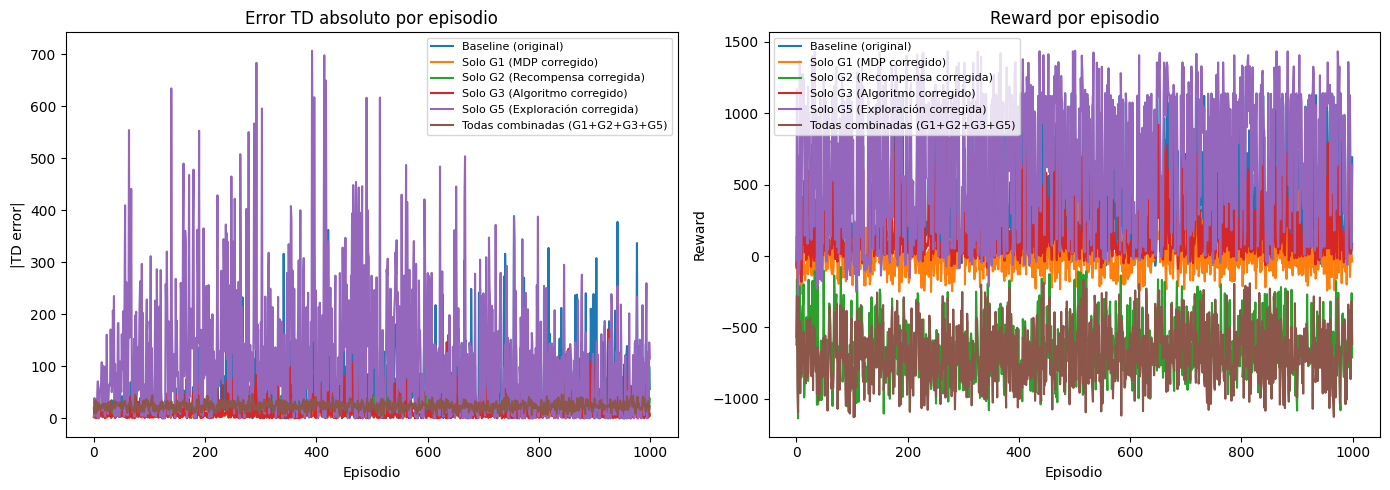

In [18]:
results = []
results.append(run_experiment("Baseline (original)", transition_original, reward_original, alpha_original, epsilon_original))
results.append(run_experiment("Solo G1 (MDP corregido)", transition_g1_fix, reward_original, alpha_original, epsilon_original))
results.append(run_experiment("Solo G2 (Recompensa corregida)", transition_original, reward_g2_fix, alpha_original, epsilon_original))
results.append(run_experiment("Solo G3 (Algoritmo corregido)", transition_original, reward_original, alpha_g3_fix, epsilon_original))
results.append(run_experiment("Solo G5 (Exploración corregida)", transition_original, reward_original, alpha_original, epsilon_g5_fix))
results.append(run_experiment("Todas combinadas (G1+G2+G3+G5)", transition_g1_fix, reward_g2_fix, alpha_g3_fix, epsilon_g5_fix))
 
print("\n\n=== TABLA COMPARATIVA ===")
print(f"{'Experimento':35s} {'Reward':>10s} {'TD error':>10s} {'Varianza':>12s} {'Acción dom.':>12s} {'%':>6s}")
for r in results:
    print(f"{r['name']:35s} {r['reward_tail']:10.2f} {r['td_tail']:10.2f} "
          f"{r['variance']:12.2f} {str(r['dominant'])+' u':>12s} {r['dominant_pct']*100:5.1f}%")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for r in results:
    axes[0].plot(r['td_errors'], label=r['name'])
    axes[1].plot(r['rewards'], label=r['name'])
axes[0].set_title('Error TD absoluto por episodio')
axes[0].set_xlabel('Episodio'); axes[0].set_ylabel('|TD error|'); axes[0].legend(fontsize=8)
axes[1].set_title('Reward por episodio')
axes[1].set_xlabel('Episodio'); axes[1].set_ylabel('Reward'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('comparacion_curvas_6_4.png', dpi=150)
plt.show()

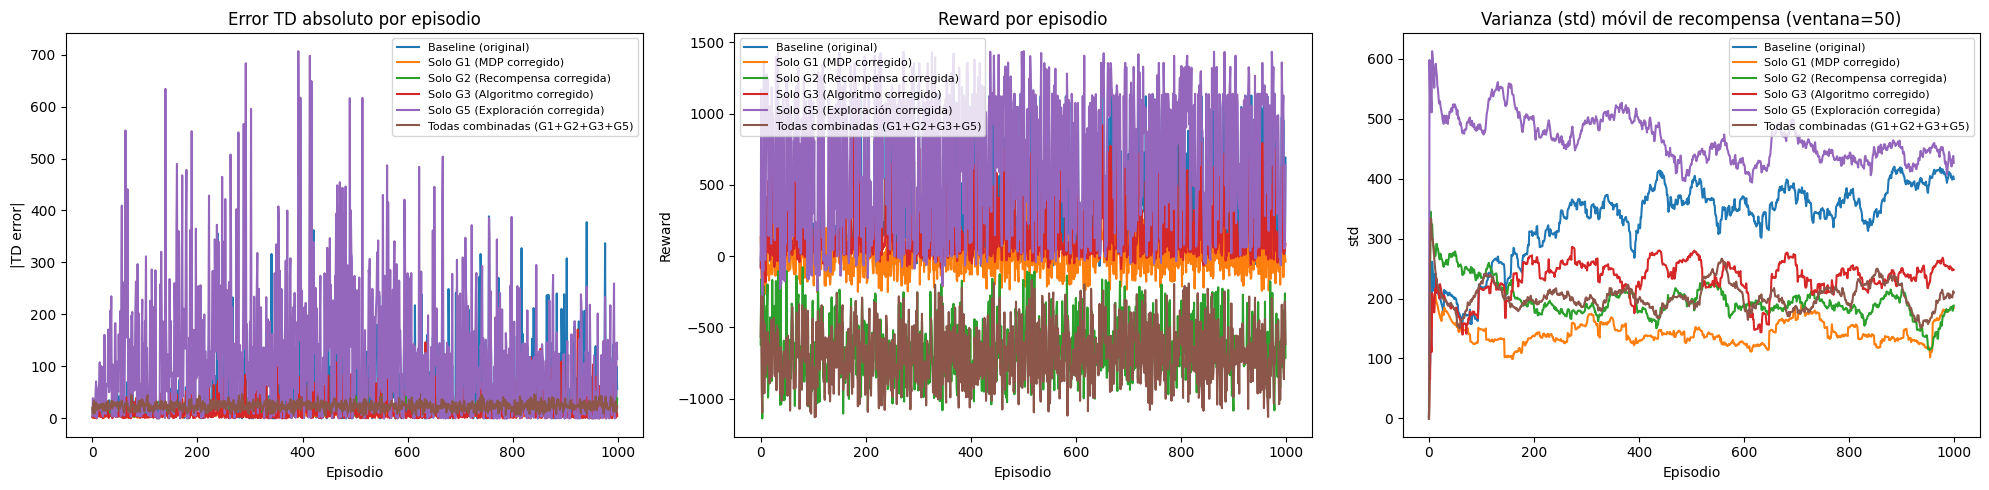

In [20]:
def rolling_std(rewards, window=50):
    return [np.std(rewards[max(0, i - window + 1):i + 1]) for i in range(len(rewards))]
 
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
 
for r in results:
    axes[0].plot(r['td_errors'], label=r['name'])
    axes[1].plot(r['rewards'], label=r['name'])
    axes[2].plot(rolling_std(r['rewards'], window=50), label=r['name'])
 
axes[0].set_title('Error TD absoluto por episodio')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('|TD error|')
axes[0].legend(fontsize=8)
 
axes[1].set_title('Reward por episodio')
axes[1].set_xlabel('Episodio')
axes[1].set_ylabel('Reward')
axes[1].legend(fontsize=8)
 
axes[2].set_title('Varianza (std) móvil de recompensa (ventana=50)')
axes[2].set_xlabel('Episodio')
axes[2].set_ylabel('std')
axes[2].legend(fontsize=8)
 
plt.tight_layout()
plt.show()